In [1]:
import pandas as pd
from sympy.ntheory import digits

from email_outreach.experiment_utils.metric_loader import load_experiment_metrics
from email_outreach.ml.shallow_autoencoder.abstract_contextual_model import AbstractContextualModel
from email_outreach.utils.constants import ROOT_FOLDER
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def get_precisions_recalls(path: Path, quantiles=1 - np.linspace(start=0, stop=1, num=100)):
    experiments: list[list] = load_experiment_metrics(path)
    recalls: list[float] = []
    precisions: list[float] = []
    for experiment in experiments:
        recall, precision = AbstractContextualModel.calculate_recall_precision_at_quantiles(experiment,
                                                                                            quantiles=quantiles)[1:3]

        recalls.append(recall)
        precisions.append(precision)

    return recalls, precisions

In [37]:
def delta_pct(lhs: np.ndarray, rhs: np.ndarray, decimals: int = 2 ) -> np.ndarray:
    return ((lhs-rhs)*100).round(decimals)

In [3]:
baseline_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "baseline_v2"
geometric_alpha_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "geometric_alpha_v2"
lin_alpha_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "linear_alpha_v2"
adaptive_alpha_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "adaptive_alpha_v2"
exp_template_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "exp_template_v2"
non_naive_f_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "non_naive_f_v2"
revised_s_a_b_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "revised_s_a_b_v2"
revised_s_revised_f_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "revised_s_revised_f_v2"
p_var_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "p_var_v2"

In [4]:
baseline_recalls, baseline_precisions = get_precisions_recalls(baseline_path)
geometric_alpha_recalls, geometric_alpha_precisions = get_precisions_recalls(geometric_alpha_path)
lin_alpha_recalls, lin_alpha_precisions = get_precisions_recalls(lin_alpha_path)
adaptive_alpha_recalls, adaptive_alpha_precisions = get_precisions_recalls(adaptive_alpha_path)
exp_template_recalls, exp_template_precisions = get_precisions_recalls(exp_template_path)
non_naive_f_recalls, non_naive_f_precisions = get_precisions_recalls(non_naive_f_path)
revised_s_a_b_recalls, revised_s_a_b_precisions = get_precisions_recalls(revised_s_a_b_path)
revised_s_revised_f_recalls, revised_s_revised_f_precisions = get_precisions_recalls(revised_s_revised_f_path)
p_var_recalls, p_var_precisions = get_precisions_recalls(p_var_path)

### All

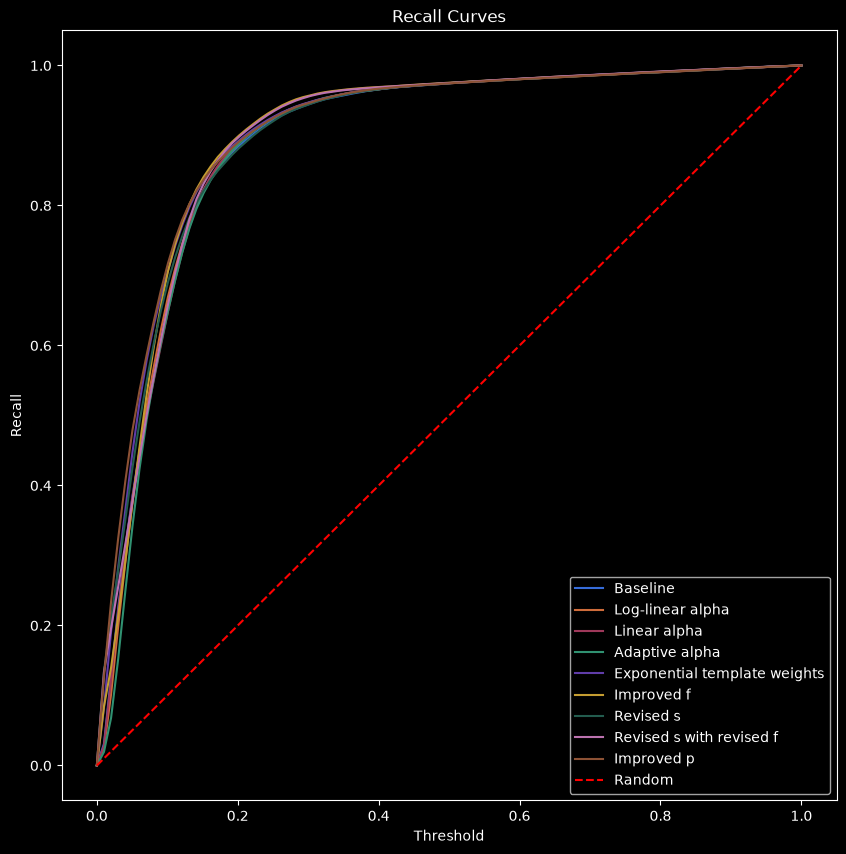

In [5]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0), label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(geometric_alpha_recalls).mean(axis=0),
         label="Log-linear alpha")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(lin_alpha_recalls).mean(axis=0), label="Linear alpha")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(adaptive_alpha_recalls).mean(axis=0),
         label="Adaptive alpha")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(exp_template_recalls).mean(axis=0),
         label="Exponential template weights")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(non_naive_f_recalls).mean(axis=0), label="Improved f")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(revised_s_a_b_recalls).mean(axis=0),
         label="Revised s")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(revised_s_revised_f_recalls).mean(axis=0),
         label="Revised s with revised f")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(p_var_recalls).mean(axis=0), label="Improved p")

plt.plot([0,1], [0,1], label="Random", color = "red", linestyle = "--")

plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

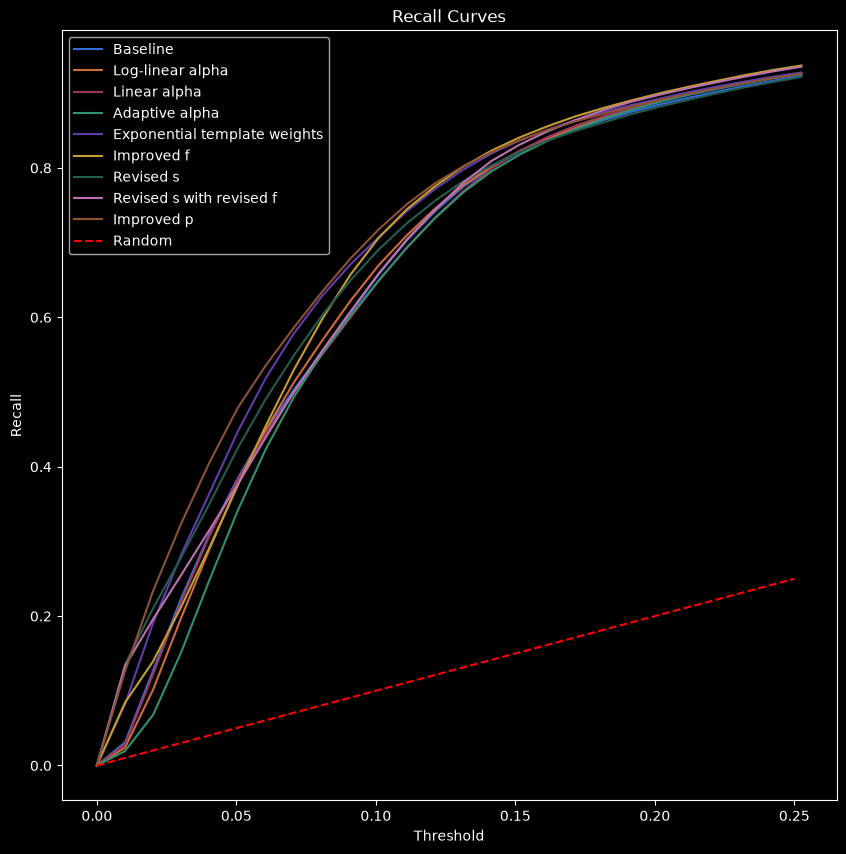

In [6]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(baseline_recalls).mean(axis=0)[:26], label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(geometric_alpha_recalls).mean(axis=0)[:26],
         label="Log-linear alpha")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(lin_alpha_recalls).mean(axis=0)[:26], label="Linear alpha")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(adaptive_alpha_recalls).mean(axis=0)[:26],
         label="Adaptive alpha")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(exp_template_recalls).mean(axis=0)[:26],
         label="Exponential template weights")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(non_naive_f_recalls).mean(axis=0)[:26], label="Improved f")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(revised_s_a_b_recalls).mean(axis=0)[:26],
         label="Revised s")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(revised_s_revised_f_recalls).mean(axis=0)[:26],
         label="Revised s with revised f")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(p_var_recalls).mean(axis=0)[:26], label="Improved p")

plt.plot([0,0.25], [0,0.25], label="Random", color = "red", linestyle = "--")

plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

### Baseline vs Log-Linear alpha

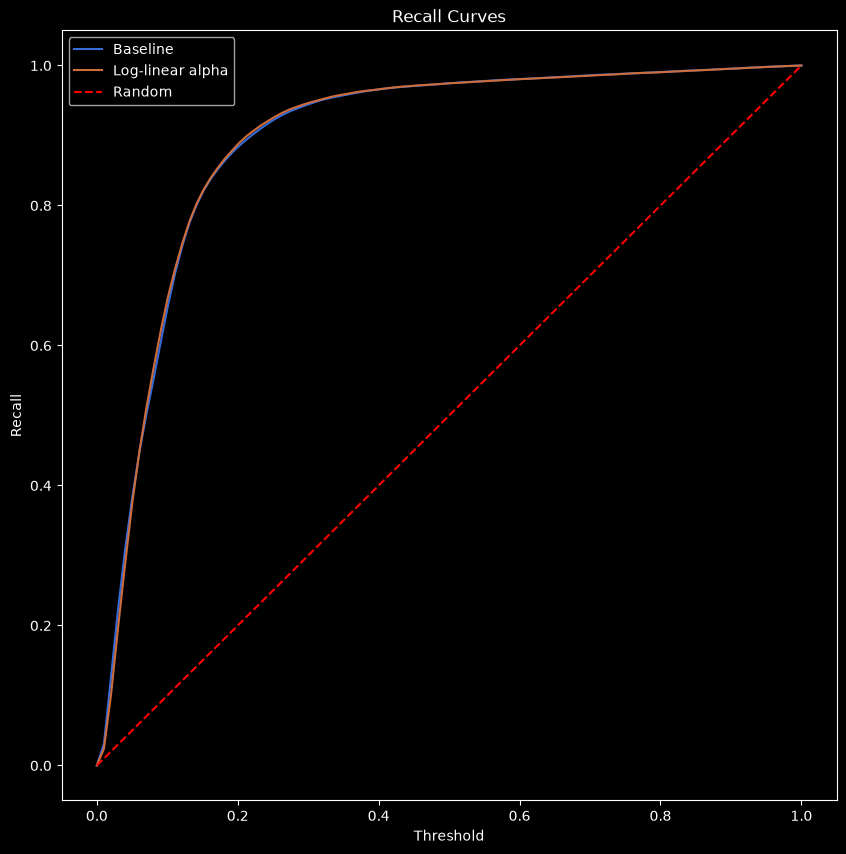

In [7]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0), label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(geometric_alpha_recalls).mean(axis=0),
         label="Log-linear alpha")

plt.plot([0,1], [0,1], label="Random", color = "red", linestyle = "--")
plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

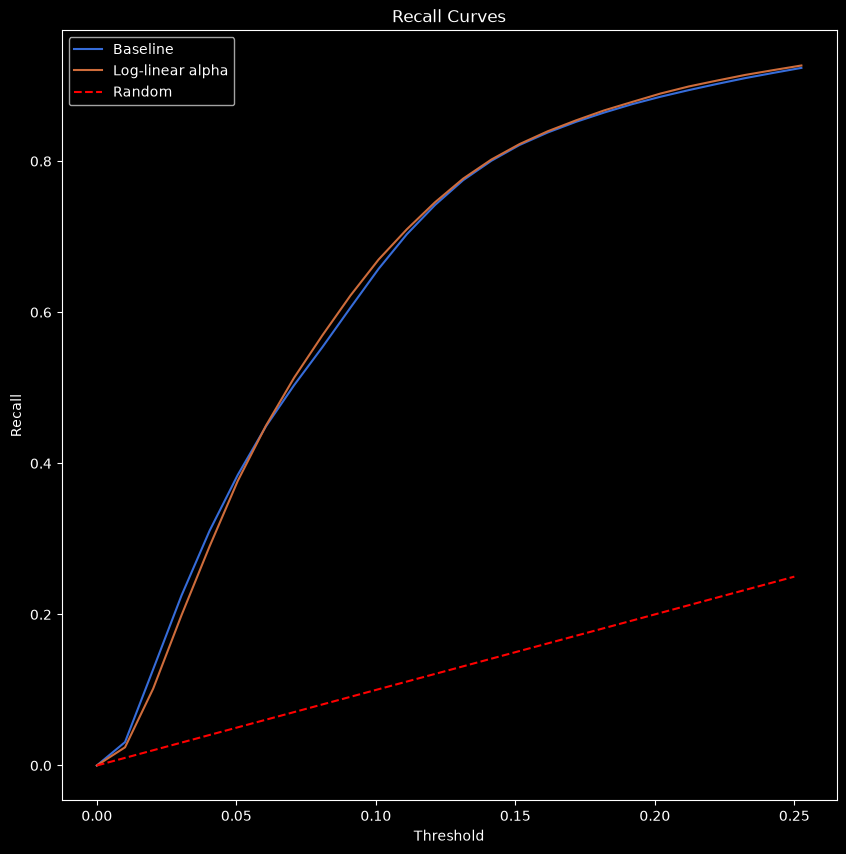

In [8]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(baseline_recalls).mean(axis=0)[:26], label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(geometric_alpha_recalls).mean(axis=0)[:26],
         label="Log-linear alpha")

plt.plot([0,0.25], [0,0.25], label="Random", color = "red", linestyle = "--")

plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

In [42]:
delta_pct(
    lhs = np.array(geometric_alpha_recalls).mean(axis=0),
    rhs = np.array(baseline_recalls).mean(axis=0),
    decimals=1
)

array([ 0. , -0.7, -2.6, -2.6, -2.1, -0.8,  0.1,  1. ,  1.6,  1.6,  1.2,
        0.7,  0.4,  0.2,  0.2,  0.1,  0.2,  0.2,  0.3,  0.3,  0.4,  0.5,
        0.4,  0.4,  0.4,  0.3,  0.3,  0.3,  0.3,  0.2,  0.2,  0.1,  0.1,
        0.1,  0.1,  0.1,  0.1,  0.1,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. , -0. , -0. , -0. , -0. , -0. , -0. ,
       -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. ,
       -0. , -0. , -0. , -0.1, -0. , -0. , -0. , -0. , -0. , -0. ,  0. ,
       -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. ,
        0. ,  0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. ,
        0. ])

### Baseline vs Linear alpha

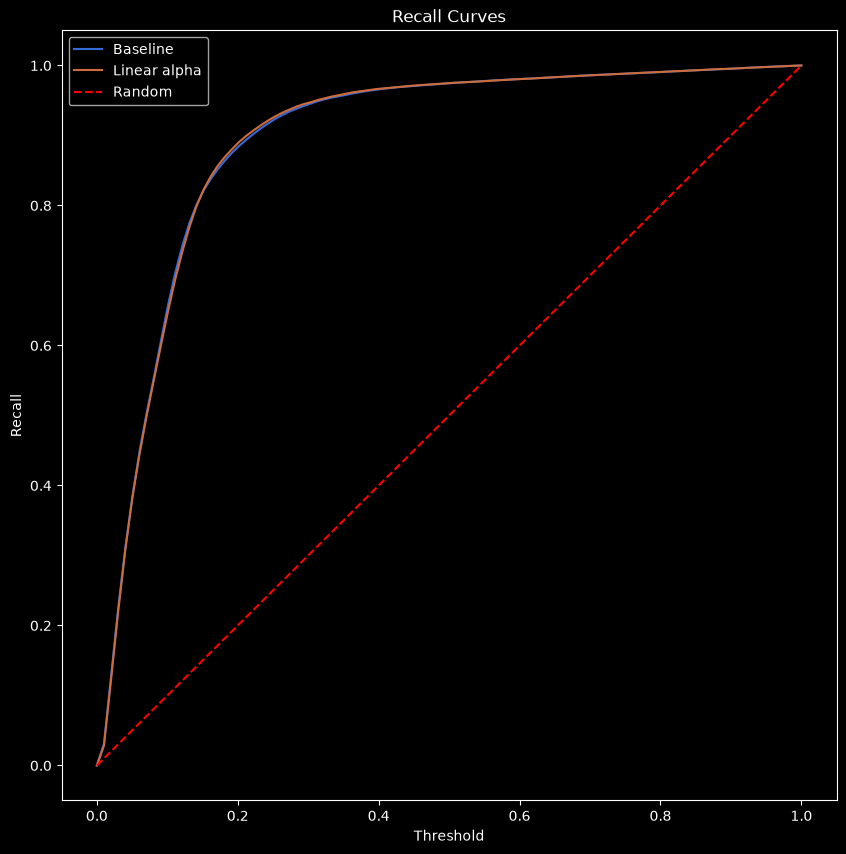

In [9]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0), label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(lin_alpha_recalls).mean(axis=0),
         label="Linear alpha")

plt.plot([0,1], [0,1], label="Random", color = "red", linestyle = "--")

plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

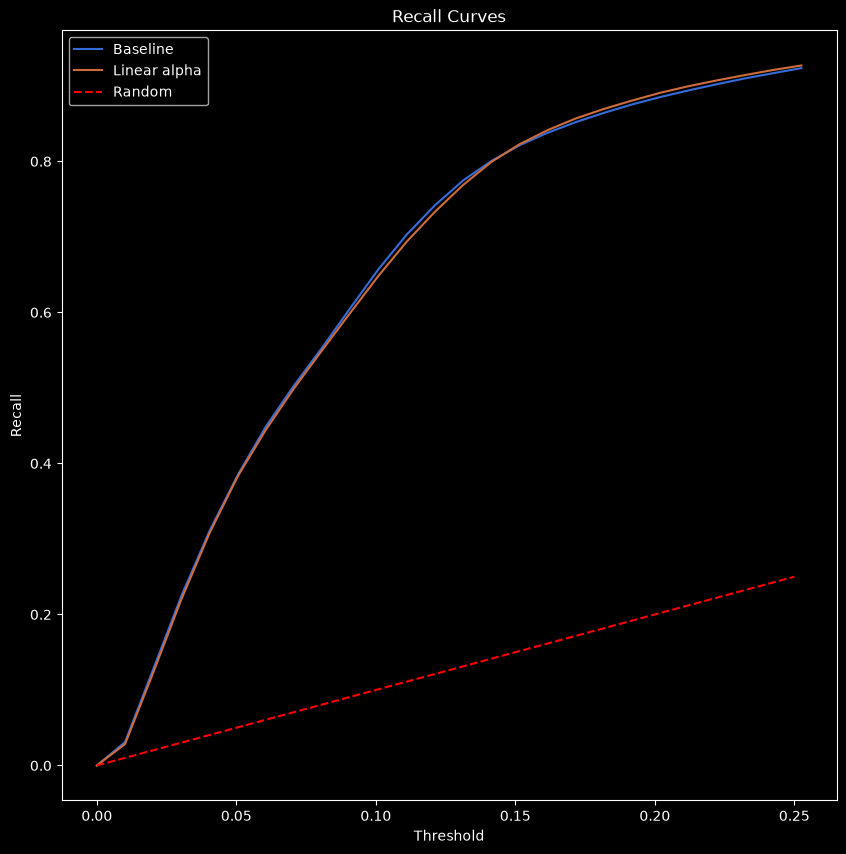

In [10]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(baseline_recalls).mean(axis=0)[:26], label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(lin_alpha_recalls).mean(axis=0)[:26],
         label="Linear alpha")

plt.plot([0,0.25], [0,0.25], label="Random", color = "red", linestyle = "--")

plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

In [43]:
delta_pct(
    lhs = np.array(lin_alpha_recalls).mean(axis=0),
    rhs = np.array(baseline_recalls).mean(axis=0),
    decimals=1
)

array([ 0. , -0.3, -0.4, -0.5, -0.3, -0.2, -0.4, -0.4, -0.3, -0.6, -0.9,
       -0.9, -0.9, -0.6, -0.1,  0.1,  0.4,  0.5,  0.5,  0.5,  0.6,  0.6,
        0.5,  0.4,  0.4,  0.4,  0.3,  0.3,  0.3,  0.3,  0.2,  0.2,  0.1,
        0.2,  0.2,  0.2,  0.2,  0.1,  0.1,  0.1,  0.1,  0. ,  0. ,  0. ,
        0. ,  0.1,  0.1,  0. ,  0. ,  0. ,  0. ,  0. , -0. , -0. , -0. ,
       -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. , -0. , -0. , -0. , -0. , -0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. , -0. , -0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. ,  0. ,
        0. ])

### Baseline vs Adaptive alpha

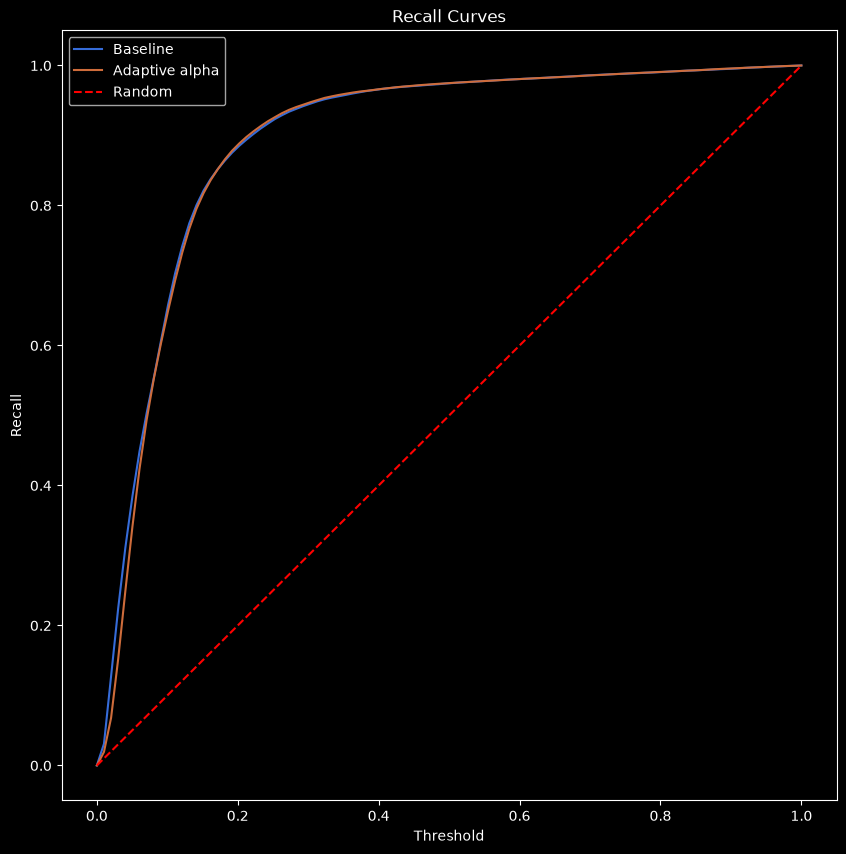

In [11]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0), label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(adaptive_alpha_recalls).mean(axis=0),
         label="Adaptive alpha")

plt.plot([0,1], [0,1], label="Random", color = "red", linestyle = "--")

plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

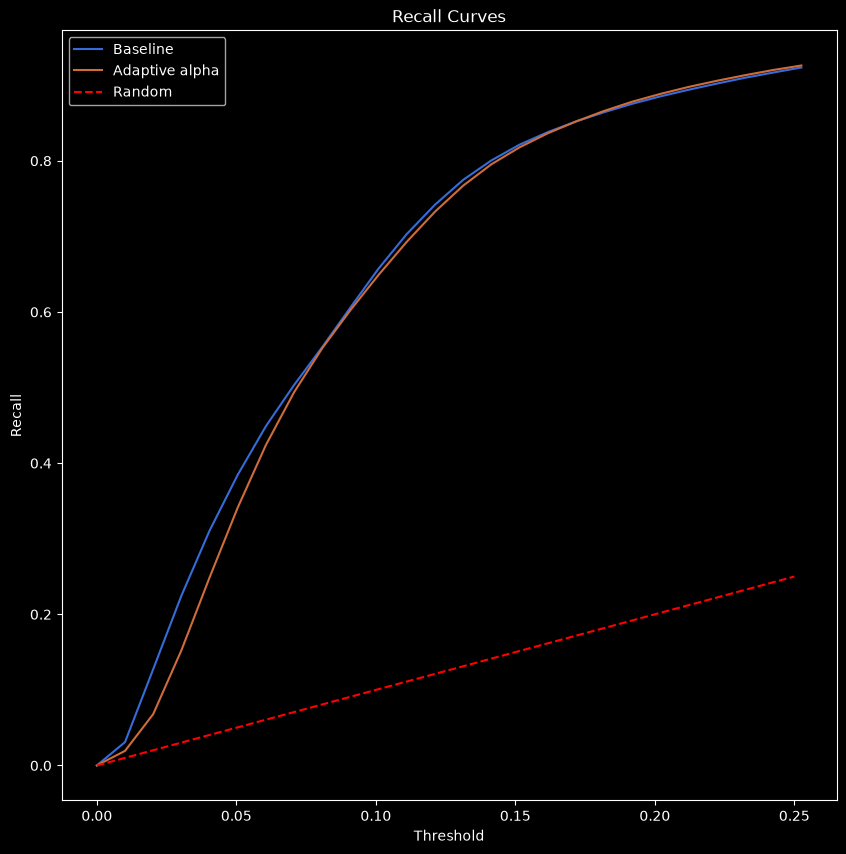

In [12]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(baseline_recalls).mean(axis=0)[:26], label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(adaptive_alpha_recalls).mean(axis=0)[:26],
         label="Adaptive alpha")

plt.plot([0,0.25], [0,0.25], label="Random", color = "red", linestyle = "--")

plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

In [44]:
delta_pct(
    lhs = np.array(adaptive_alpha_recalls).mean(axis=0),
    rhs = np.array(baseline_recalls).mean(axis=0),
    decimals=1
)

array([ 0. , -1.2, -5.9, -7.2, -6.2, -4.3, -2.5, -1. , -0.1, -0.4, -0.8,
       -1. , -0.9, -0.8, -0.5, -0.4, -0.2, -0. ,  0.2,  0.3,  0.3,  0.4,
        0.4,  0.3,  0.3,  0.3,  0.3,  0.3,  0.3,  0.2,  0.2,  0.2,  0.2,
        0.2,  0.2,  0.2,  0.1,  0.1,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0.1,  0.1,  0. ,  0.1,  0. ,  0. ,  0. ,  0. ,  0. , -0. ,
       -0. , -0. , -0. , -0. , -0. ,  0. ,  0. , -0. , -0. , -0. , -0. ,
       -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. , -0. ,  0. , -0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. , -0. ,  0. ,  0. ,  0. ,  0. ,
        0. ])

### Baseline vs Exponential template weights

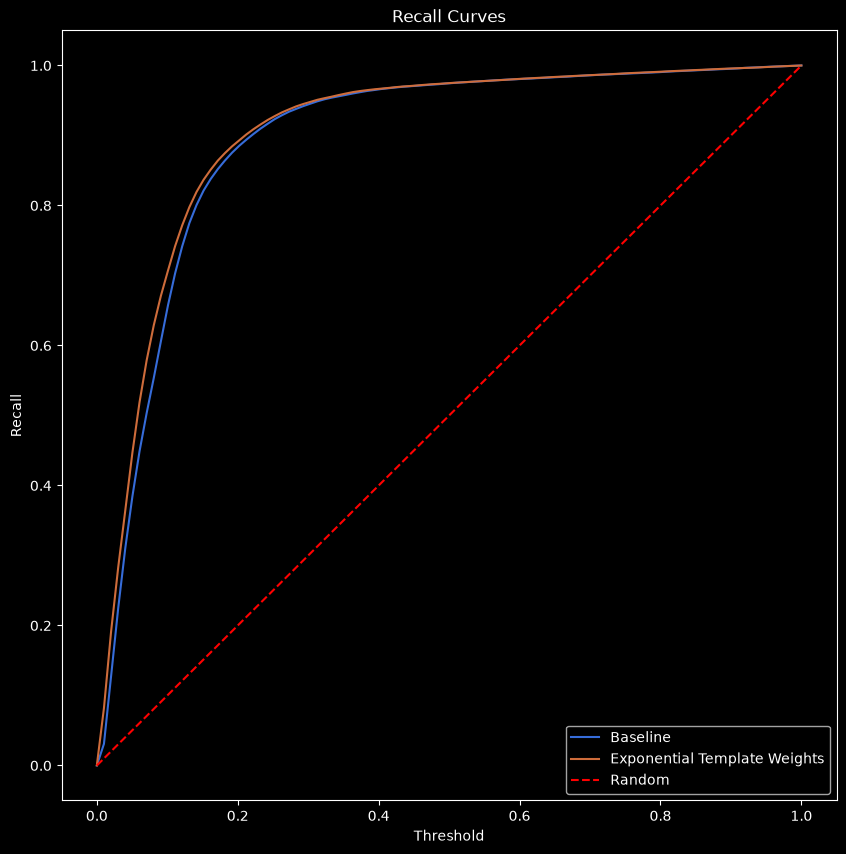

In [13]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0), label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(exp_template_recalls).mean(axis=0),
         label="Exponential Template Weights")

plt.plot([0,1], [0,1], label="Random", color = "red", linestyle = "--")

plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

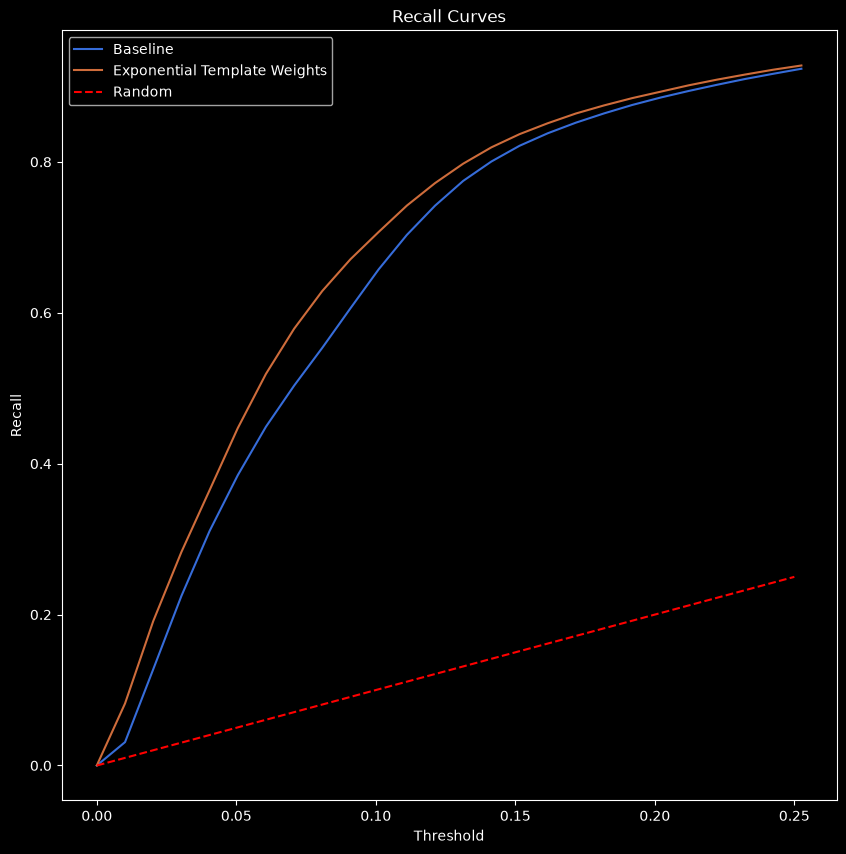

In [14]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(baseline_recalls).mean(axis=0)[:26], label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(exp_template_recalls).mean(axis=0)[:26],
         label="Exponential Template Weights")

plt.plot([0,0.25], [0,0.25], label="Random", color = "red", linestyle = "--")

plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

In [47]:
delta_pct(
    lhs = np.array(exp_template_recalls).mean(axis=0),
    rhs = np.array(baseline_recalls).mean(axis=0),
    decimals=1
)

array([ 0. ,  5.1,  6.4,  5.8,  5.4,  6.2,  7. ,  7.5,  7.5,  6.5,  5. ,
        3.9,  3. ,  2.3,  1.9,  1.5,  1.3,  1.2,  1.1,  0.9,  0.8,  0.7,
        0.7,  0.6,  0.5,  0.4,  0.4,  0.3,  0.4,  0.3,  0.3,  0.2,  0.2,
        0.1,  0.2,  0.2,  0.2,  0.2,  0.1,  0.1,  0.1,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
       -0. , -0. , -0. , -0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0.1,  0. ,  0.1,
        0.1,  0.1,  0.1,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. ,
        0. ])

### Baseline vs Improved f

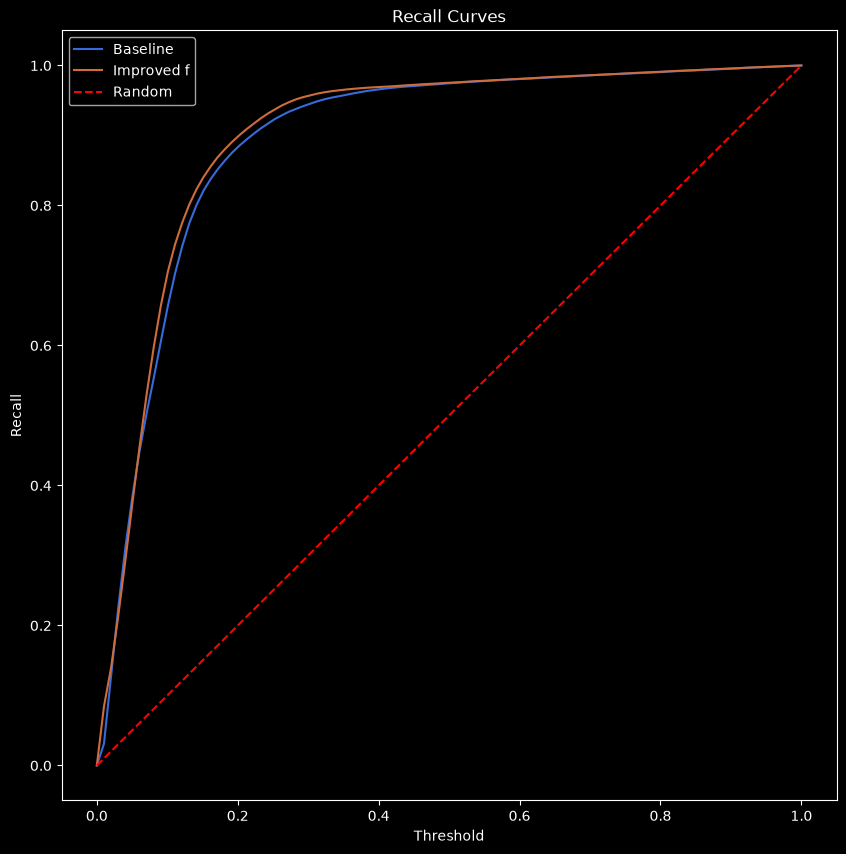

In [15]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0), label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(non_naive_f_recalls).mean(axis=0),
         label="Improved f")

plt.plot([0,1], [0,1], label="Random", color = "red", linestyle = "--")

plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

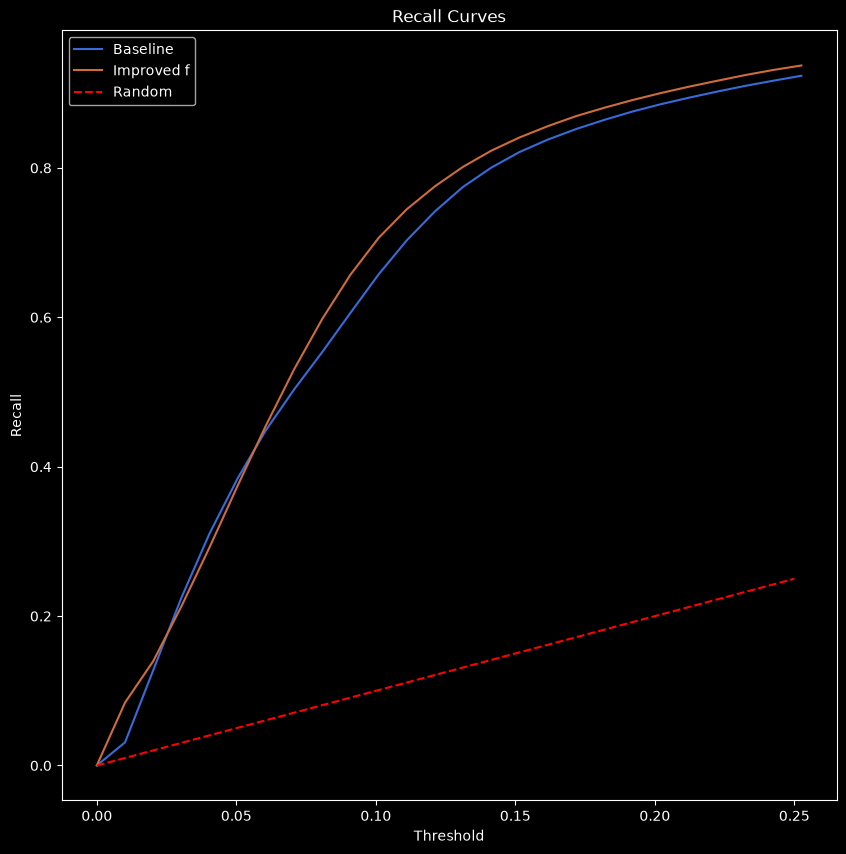

In [16]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(baseline_recalls).mean(axis=0)[:26], label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(non_naive_f_recalls).mean(axis=0)[:26],
         label="Improved f")

plt.plot([0,0.25], [0,0.25], label="Random", color = "red", linestyle = "--")

plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

In [49]:
delta_pct(
    lhs = np.array(non_naive_f_recalls).mean(axis=0),
    rhs = np.array(baseline_recalls).mean(axis=0),
    decimals=1
)

array([ 0. ,  5.3,  1.2, -1.2, -1.9, -1. ,  0.6,  2.7,  4.4,  5.1,  4.9,
        4.2,  3.4,  2.7,  2.3,  1.9,  1.8,  1.7,  1.6,  1.5,  1.5,  1.5,
        1.4,  1.4,  1.4,  1.4,  1.4,  1.4,  1.4,  1.3,  1.2,  1.1,  1. ,
        0.9,  0.8,  0.8,  0.7,  0.6,  0.5,  0.4,  0.3,  0.2,  0.2,  0.2,
        0.2,  0.2,  0.1,  0.1,  0.1,  0.1,  0.1,  0. ,  0.1,  0.1,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0.1,  0.1,  0.1,
        0. ,  0. ,  0. ,  0. ,  0. , -0. ,  0. ,  0. ,  0. ,  0. ,  0.1,
        0.1,  0.1,  0.1,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. , -0. , -0. ,  0. ,  0. ,  0. ,
        0. ])

### Baseline vs Revised s

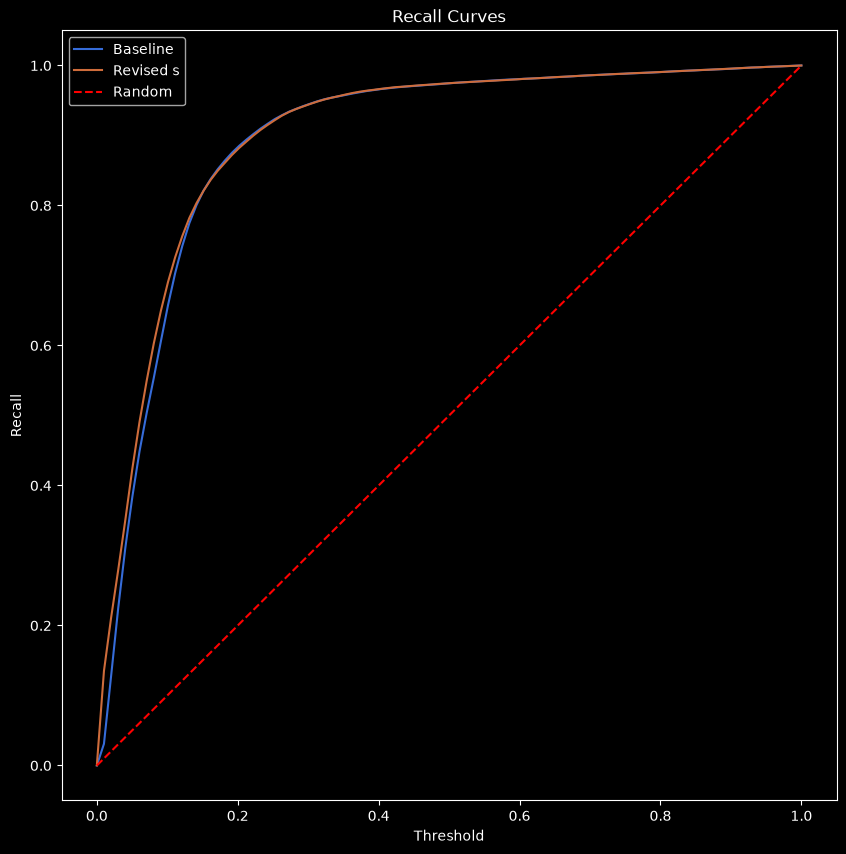

In [17]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0), label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(revised_s_a_b_recalls).mean(axis=0),
         label="Revised s")

plt.plot([0,1], [0,1], label="Random", color = "red", linestyle = "--")

plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

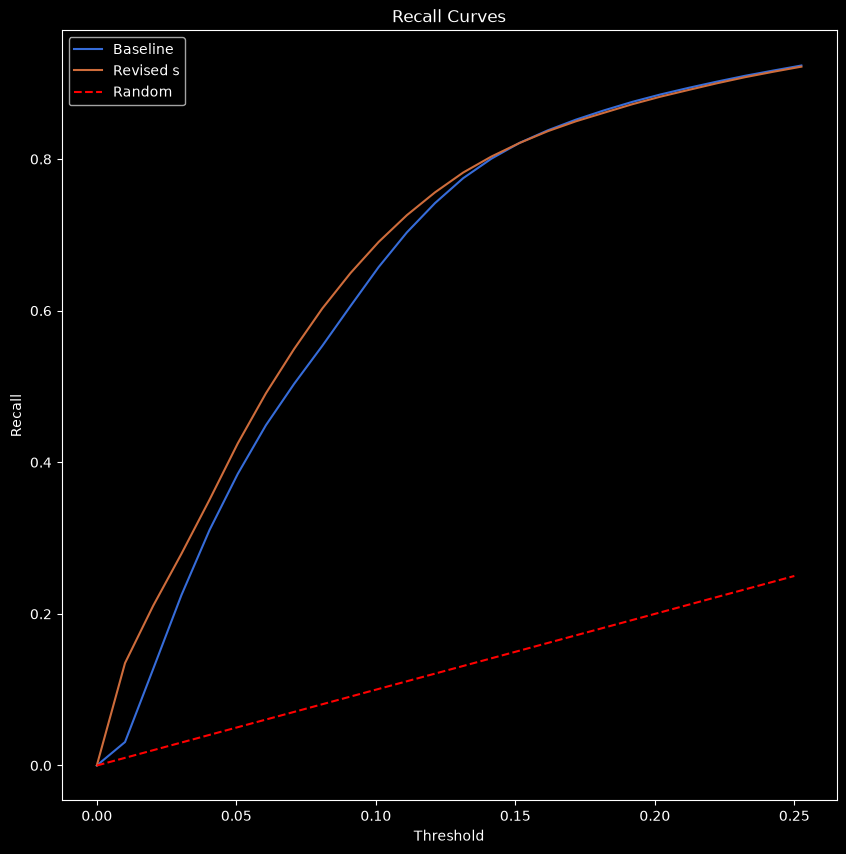

In [18]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(baseline_recalls).mean(axis=0)[:26], label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(revised_s_a_b_recalls).mean(axis=0)[:26],
         label="Revised s")

plt.plot([0,0.25], [0,0.25], label="Random", color = "red", linestyle = "--")

plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

In [50]:
delta_pct(
    lhs = np.array(revised_s_a_b_recalls).mean(axis=0),
    rhs = np.array(baseline_recalls).mean(axis=0),
    decimals=1
)

array([ 0. , 10.4,  8.3,  5.5,  4. ,  4. ,  4.2,  4.6,  4.9,  4.4,  3.3,
        2.3,  1.4,  0.7,  0.3, -0. , -0.1, -0.2, -0.3, -0.3, -0.3, -0.3,
       -0.2, -0.2, -0.2, -0.2, -0.1, -0. , -0. , -0. , -0. , -0. , -0. ,
       -0. ,  0. ,  0.1,  0.1,  0.1,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. , -0. , -0. , -0. , -0. ,
       -0. , -0. , -0. , -0. , -0. , -0. ,  0. , -0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. , -0. , -0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. , -0. , -0. ,  0. , -0. ,  0. ,  0. ,  0. , -0. ,
        0. ,  0. ,  0. , -0. ,  0. , -0. , -0. , -0. , -0. , -0. , -0. ,
        0. ])

### Baseline vs Revised s with revised f

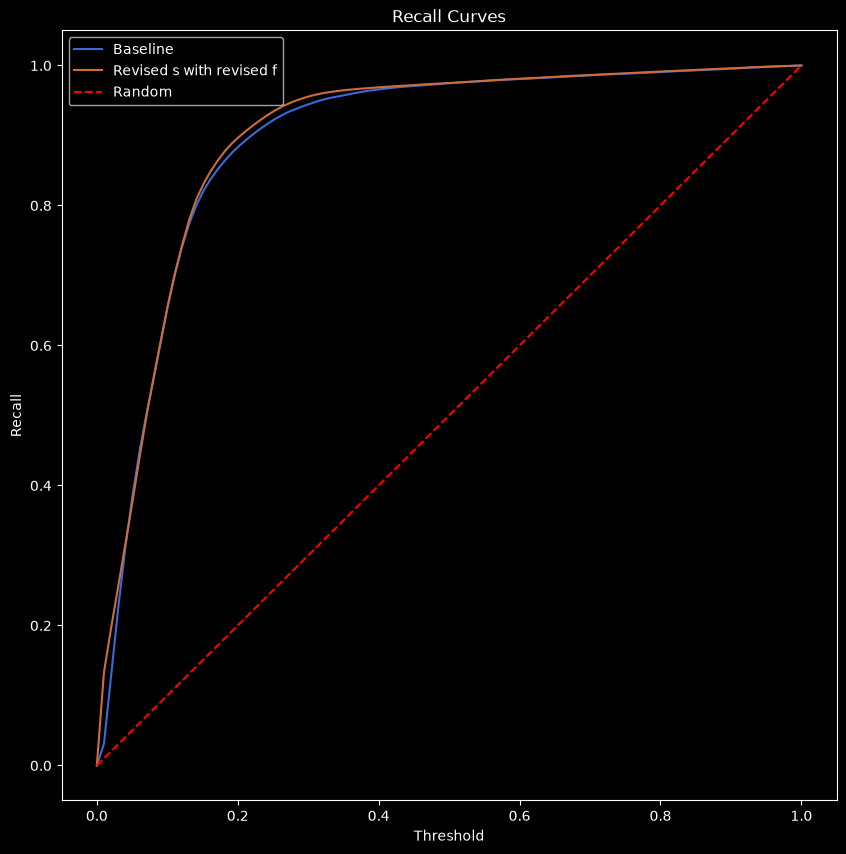

In [19]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0), label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(revised_s_revised_f_recalls).mean(axis=0),
         label="Revised s with revised f")

plt.plot([0,1], [0,1], label="Random", color = "red", linestyle = "--")

plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

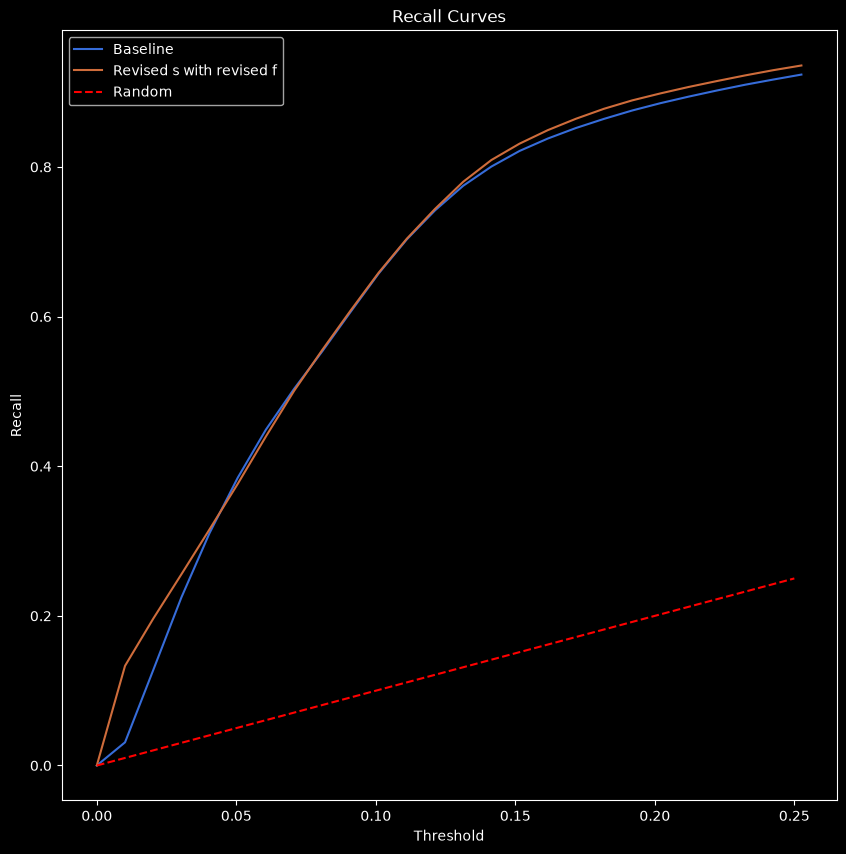

In [20]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(baseline_recalls).mean(axis=0)[:26], label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(revised_s_revised_f_recalls).mean(axis=0)[:26],
         label="Revised s with revised f")

plt.plot([0,0.25], [0,0.25], label="Random", color = "red", linestyle = "--")

plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

In [51]:
delta_pct(
    lhs = np.array(revised_s_revised_f_recalls).mean(axis=0),
    rhs = np.array(baseline_recalls).mean(axis=0),
    decimals=1
)

array([ 0. , 10.2,  6.9,  3.1,  0.5, -0.8, -0.9, -0.3,  0.2,  0.2,  0.1,
        0.1,  0.2,  0.5,  0.9,  1. ,  1.1,  1.2,  1.4,  1.4,  1.3,  1.3,
        1.3,  1.2,  1.3,  1.2,  1.2,  1.2,  1.2,  1.1,  1.1,  1. ,  0.9,
        0.8,  0.8,  0.7,  0.6,  0.5,  0.4,  0.3,  0.3,  0.2,  0.2,  0.1,
        0.1,  0.1,  0.1,  0.1,  0.1,  0.1,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,
        0.1,  0.1,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0.1,  0.1,  0.1,
        0.1,  0.1,  0.1,  0.1,  0.1,  0.1,  0. ,  0.1,  0.1,  0.1,  0.1,
        0.1,  0.1,  0.1,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ])

### Baseline vs Improved p

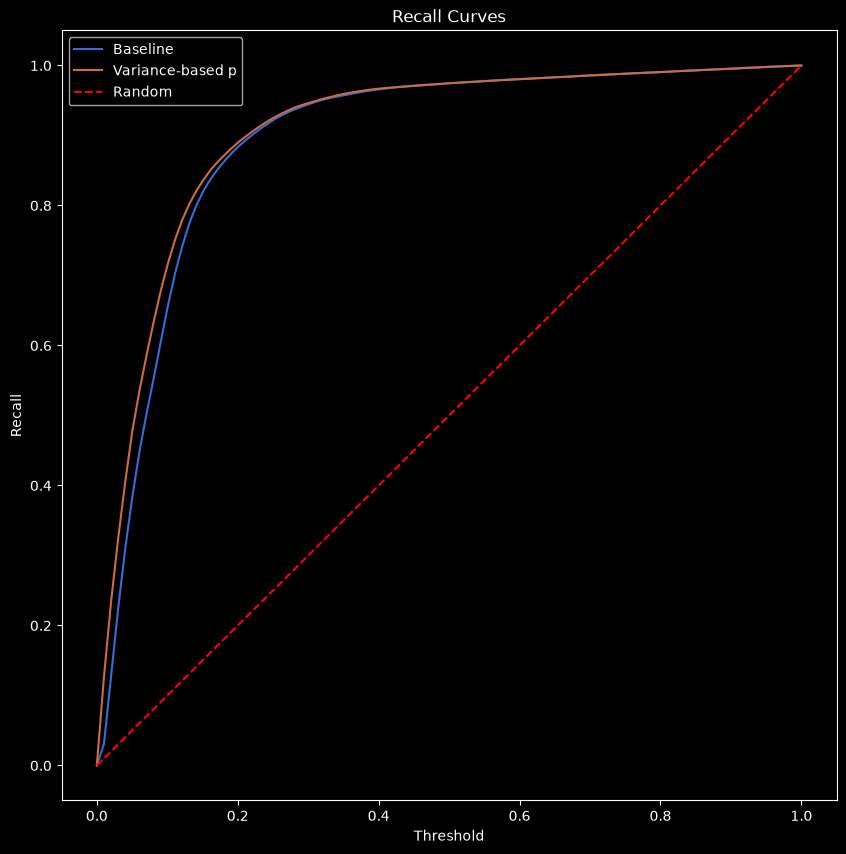

In [21]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0), label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(p_var_recalls).mean(axis=0),
         label="Variance-based p")

plt.plot([0,1], [0,1], label="Random", color = "red", linestyle = "--")

plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

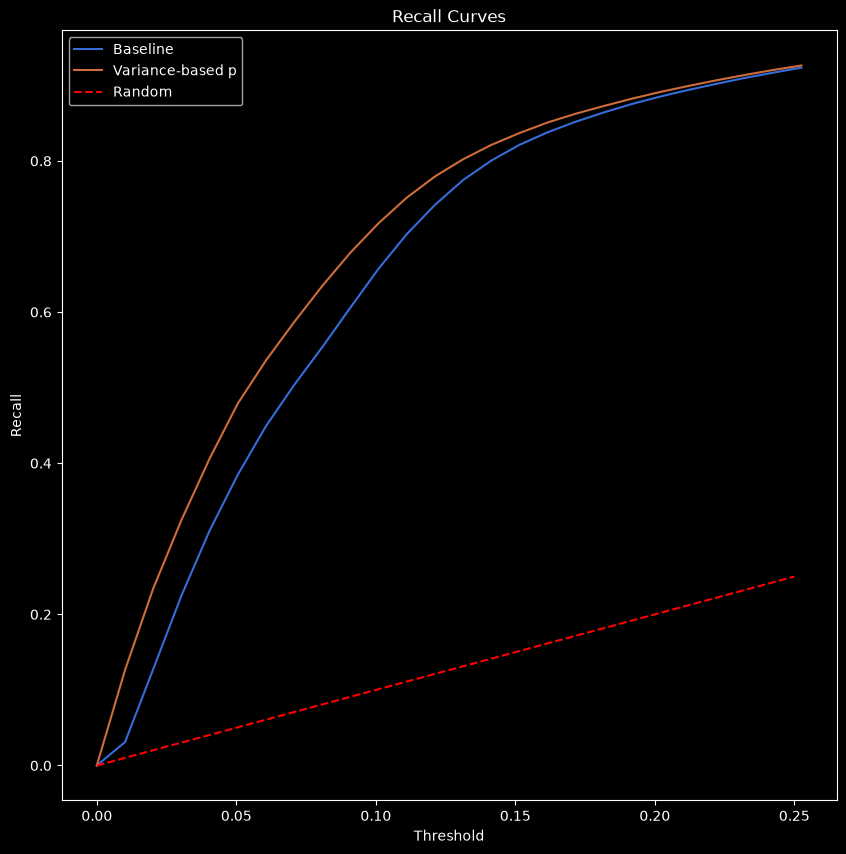

In [22]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(baseline_recalls).mean(axis=0)[:26], label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(p_var_recalls).mean(axis=0)[:26],
         label="Variance-based p")

plt.plot([0,0.25], [0,0.25], label="Random", color = "red", linestyle = "--")

plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

In [52]:
delta_pct(
    lhs = np.array(p_var_recalls).mean(axis=0),
    rhs = np.array(baseline_recalls).mean(axis=0),
    decimals=1
)

array([ 0. ,  9.5, 10.7, 10. ,  9.5,  9.4,  8.7,  8.3,  8.1,  7.3,  6. ,
        4.8,  3.8,  2.7,  2.1,  1.6,  1.3,  1.1,  0.8,  0.7,  0.6,  0.5,
        0.5,  0.4,  0.4,  0.3,  0.3,  0.2,  0.3,  0.2,  0.2,  0.1,  0.1,
        0.1,  0.2,  0.2,  0.2,  0.2,  0.1,  0.1,  0.1,  0.1,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. , -0. , -0. , -0. , -0. , -0. ,
       -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. ,
       -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. ,  0. ,
        0. ,  0. ,  0. , -0. , -0. , -0. , -0. , -0. , -0. ,  0. , -0. ,
        0. ,  0. , -0. , -0. , -0. , -0. , -0. , -0. ,  0. ,  0. , -0. ,
        0. ])